# How new concepts spread: diffusion types (RQ2 typology demo)

This notebook is a runnable demo of the **core stage** of the RQ2 experiment *"How new concepts spread: types, roles, timing"*.

The original `method.py` is a thin orchestrator that runs thirteen stage scripts in `src/` in order
(`prep -> attach -> indicators -> labels -> leiden_seeds -> typology -> roles -> leadlag -> patterns -> validation -> cases -> method_out -> freeze`).
Most of those stages rebuild yearly co-word networks from multi-GB upstream snapshots, which is too heavy for a demo.
This notebook therefore starts from the **output of the `indicators` stage** (per-concept, per-year diffusion indicators)
and runs the **`typology` stage (`src/typology.py`)**, whose functions are copied here unchanged:

* **3-channel diffusion typology**: every concept is a multivariate yearly series from its first-appearance year `F` to 2024, with the channels
  `H_rar` (rarefied Shannon entropy over subfields), `RS` (Rao–Stirling diversity) and `active_subfields_3y`.
  Series are z-scaled, compared with **normalised multivariate DTW** (Sakoe–Chiba radius 3, `dtw / sqrt(len(path))`), and clustered
  with **k-medoids (FasterPAM)**. The number of clusters `k` is chosen with **Hennig's bootstrap-Jaccard stability** (the largest `k`
  whose smallest cluster Jaccard > 0.75).
* **Baselines**: B1 = entropy-only DTW typology (the iteration-2 recipe), B2 = volume terciles and a volume-only DTW clustering.
  Plus a volume-residualised variant, sensitivity analyses, rule-based cluster naming and permutation chi-square cross-tabs.

In the full run (202 screen MAIN concepts) only **k = 2** was stable (min Jaccard 0.861): *localised* (n=136) vs
*broad from the start (rapid interdisciplinary)* (n=66). The clusters were not driven by volume (AMI with volume terciles 0.014).
The demo data holds **100 of those 202 concepts**: both medoids plus a stratified sample. The full-run label of every concept is included, so the demo's clusters can be compared with the originals.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# tslearn (multivariate DTW), kmedoids (FasterPAM), loguru (logging) — NOT on Colab, always install
# (the original used tslearn 0.9.0, which needs numba>=0.61; 0.7.0 is the newest that compiles with Colab's numba 0.60)
_pip('tslearn==0.7.0', 'kmedoids==0.5.5', 'loguru==0.7.3')

# Core packages — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0', 'numba==0.60.0')

In [2]:
# --- original import block of src/typology.py ---
from __future__ import annotations

import math

import numpy as np
import pandas as pd
from loguru import logger
from scipy.stats import spearmanr
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

# --- extra imports for the notebook (common.py helpers, output folder, timing, plotting) ---
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-3/experiment-8/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
print(f"{len(examples)} concepts loaded; example: {examples[0]['concept_id']} '{examples[0]['phrase']}' (F={examples[0]['F']}, "
      f"{examples[0]['origin_group']}) -> full-run type: {examples[0]['full_run_cluster_name']}")

100 concepts loaded; example: c_02792d2208de 'rainbow connection number' (F=2010, F17:Computer Science) -> full-run type: localised


## Configuration

All tunable parameters of `src/typology.py` sit here, with the **original values** (full run, 202 concepts) in the comments.
The demo uses the original values for every parameter except the population size. It clusters the 100 concepts shipped in
`mini_demo_data.json` instead of all 202, and the whole notebook still runs in about a minute on a CPU.
For a very quick smoke test, lower `N_CONCEPTS` (≥ 30 is needed so that every cluster keeps ≥ 5 members for the description step) and `B_BOOT`.

In [5]:
N_CONCEPTS = 100          # number of concepts (of the 100 in mini_demo_data.json) to cluster; original: all 202 screen MAIN
K_RANGE = list(range(2, 8 + 1))   # candidate numbers of clusters; original: list(range(2, 9))
B_BOOT = 200              # bootstrap resamples for Hennig Jaccard stability; original: 200
JAC_MIN = 0.75           # a cluster is 'stable' if its mean bootstrap Jaccard > 0.75 (original)
DTW_RADIUS = 3           # Sakoe-Chiba band radius (years) of the multivariate DTW (original)
B_SENS = 100              # bootstrap resamples for the volume-residualised variant and sensitivities; original: 100
N_PERM = 10000             # permutations for the cross-tab chi-square tests; original: 10000
N_PERM_EXPL = 2000        # permutations for the exploratory finer-k cross-tabs; original: 2000

CH = ["H_rar", "RS", "active_subfields_3y"]              # the 3 diffusion channels
CH_RAR = ["H_rar", "RS_rar", "richness_rar"]             # fully rarefied channel set (sensitivity)

# vendored iteration-2 config (vendor/config.py SPEC['typology']) used by the entropy-only baseline B1
S = dict(typology=dict(channels=["strength_growth", "beta_sim_rar", "beta_sne_rar", "P_rar", "closure", "btw_pct", "H"],
                       ages=list(range(0, 9)), max_missing=3, max_fill=2, k_range=[2, 3, 4, 5, 6],
                       sakoe_chiba_radius=2, boot=200, jaccard_min=0.75))

# output folders (replace the repository's typology/ and results/ folders)
TYP = Path("demo_out/typology"); RES = Path("demo_out/results")
TYP.mkdir(parents=True, exist_ok=True); RES.mkdir(parents=True, exist_ok=True)

## Rebuild the input tables from the demo data

The original stage reads three files: `results/indicators/concept_year_indicators_hyd.parquet` (one row per concept × year),
`work/pool_active.parquet` (one row per concept: first year `F`, origin field, retrieval route, population flags) and
`results/labels/groups.csv` (the emergence group `E_up` and closure tercile, which are used only in the cross-tabs).
Here the same three DataFrames (`ind`, `pool`, `grp`) are rebuilt from the JSON and restricted to the first `N_CONCEPTS` concepts.

In [6]:
ex_sel = examples[:N_CONCEPTS]
rows = []
for e in ex_sel:
    yrs = e["years"]
    for i in range(len(yrs["year"])):
        rows.append(dict(concept_id=e["concept_id"], **{k: v[i] for k, v in yrs.items()}, F=e["F"], fold=e["fold"]))
ind = pd.DataFrame(rows)
for col in ["H", "H_rar", "RS", "RS_rar", "richness_rar"]:
    ind[col] = ind[col].astype(float)            # JSON null -> NaN (the missing rule in build_series relies on NaN)
pool = pd.DataFrame([{k: v for k, v in e.items() if k != "years" and not k.startswith("full_run")} for e in ex_sel])
pool = pool.rename(columns={"E_up_group": "group"})
grp = pool.set_index("concept_id")[["group", "closure_tercile"]]
full_ref = pd.DataFrame([{k: e[k] for k in ("concept_id", "full_run_cluster_name", "full_run_cluster_B1_name",
                                            "full_run_B2_vol_tercile", "full_run_is_medoid")} for e in ex_sel])
print(ind.shape, pool.shape)
ind.head()

(1638, 13) (100, 15)


,concept_id,year,age,vol,vol3,H,H_rar,RS,RS_rar,richness_rar,active_subfields_3y,F,fold
0,c_02792d2208de,2008,-2.0,1,1,-0.000000,NaN,0.000000,NaN,NaN,0,2010,screen
1,c_02792d2208de,2009,-1.0,1,2,0.693147,NaN,0.155733,NaN,NaN,0,2010,screen
2,c_02792d2208de,2010,0.0,6,8,0.562335,NaN,0.116800,NaN,NaN,2,2010,screen
3,c_02792d2208de,2011,1.0,20,27,0.803712,0.759886,0.237888,0.211222,2.64,3,2010,screen
4,c_02792d2208de,2012,2.0,25,51,0.679888,0.520843,0.192742,0.188740,2.44,3,2010,screen


## Shared helpers (from `src/common.py` and the vendored `vendor/analysis_patterns.py`)

* `wilson`: Wilson score CI for a share. `write_json` / `clean`: JSON-safe output.
* `_cluster`: FasterPAM k-medoids on a precomputed distance matrix.
* `_stability`: **Hennig (2007) bootstrap-Jaccard stability**. Resample concepts with replacement, recluster, and for each original
  cluster record the best Jaccard overlap with any bootstrap cluster. Then average over the `B` resamples.
* `_series_tensor`: the iteration-2 series builder used by the entropy-only baseline (fixed ages 0..8, z-scored over the pool).

In [7]:
# ---- from src/common.py
def clean(o):
    '''JSON-safe conversion (NaN -> None, numpy -> python).'''
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating, float)):
        v = float(o)
        return None if not math.isfinite(v) else v
    if isinstance(o, np.bool_):
        return bool(o)
    if isinstance(o, np.ndarray):
        return clean(o.tolist())
    return o


def write_json(p: Path, obj) -> None:
    Path(p).parent.mkdir(parents=True, exist_ok=True)
    Path(p).write_text(json.dumps(clean(obj), indent=1))


def wilson(k: int, n: int, z: float = 1.959964) -> tuple[float, float]:
    if n == 0:
        return (np.nan, np.nan)
    p = k / n
    den = 1 + z * z / n
    c = (p + z * z / (2 * n)) / den
    h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / den
    return (c - h, c + h)


# ---- from vendor/analysis_patterns.py (vendored iteration-2 code)
def _series_tensor(ind: pd.DataFrame, channels: list[str]) -> tuple[np.ndarray, list[str], int]:
    T = S["typology"]
    scr = ind[(ind.fold == "screen")].copy()
    for ch in channels:
        v = scr[ch].astype(float)
        scr[ch] = (v - v.mean()) / v.std()
    ages = T["ages"]
    X, ids, dropped = [], [], 0
    for c, g in scr.groupby("concept_id"):
        g = g.set_index("age").reindex(ages)[channels]
        missing = g.isna().any(axis=1).sum()
        if missing > T["max_missing"]:
            dropped += 1
            continue
        g = g.ffill(limit=T["max_fill"]).bfill(limit=T["max_fill"]).fillna(0.0)
        X.append(g.values)
        ids.append(c)
    return np.array(X), ids, dropped


def _cluster(D: np.ndarray, k: int, seed: int = 0) -> np.ndarray:
    import kmedoids
    # .astype(np.int64): kmedoids returns uint64 labels, which np.bincount rejects under numpy 2.0 (Colab); the original ran numpy 2.5
    return np.asarray(kmedoids.fasterpam(D, k, random_state=seed).labels).astype(np.int64)


def _stability(D: np.ndarray, labels: np.ndarray, k: int, B: int, seed: int = 0) -> list[float]:
    rng = np.random.default_rng(seed)
    n = len(D)
    jac = np.zeros((B, k))
    for b in range(B):
        idx = np.unique(rng.integers(0, n, n))
        if len(idx) <= k:
            continue
        lb = _cluster(D[np.ix_(idx, idx)], k, seed=b)
        for ci in range(k):
            A = set(idx[labels[idx] == ci])
            best = 0.0
            for cb in range(k):
                Bs = set(idx[lb == cb])
                u = len(A | Bs)
                if u:
                    best = max(best, len(A & Bs) / u)
            jac[b, ci] = best
    return jac.mean(axis=0).tolist()

## Series construction and normalised multivariate DTW (`src/typology.py`, "series" section)

* `build_series`: one `(n_years × n_channels)` matrix per concept, covering years `F..2024`. It has a declared missing-value rule:
  if `H_rar` is NaN because the 3-year window has fewer than 10 papers, the raw `H` of the same window is used instead.
  Any other NaN becomes 0. No concept is excluded. The function also returns the share of imputed concept-years.
* `zscale`: z-scores each channel over all concept-years pooled, so the three channels get equal weight.
* `dtw_norm` / `dist_matrix`: pairwise DTW with a Sakoe–Chiba band, divided by `sqrt(len(path))`. Concepts born in
  different years have series of different lengths, and this division stops longer series from getting larger distances just for being longer.

In [8]:
def build_series(ind: pd.DataFrame, ids: list[str], channels: list[str], ages: list[int] | None = None,
                 impute: bool = True) -> tuple[dict, pd.DataFrame]:
    '''Per-concept raw (unscaled) multichannel series and the per-concept imputed share.

    Declared missing rule: H_rar NaN (vol3 < 10) -> raw H of the same window (imputed); if vol3 == 0 -> H = RS = 0 and
    count = 0 (imputed if the value was NaN); any other NaN (e.g. all window papers without a known subfield) -> 0
    (imputed). No concept is excluded.
    '''
    ser, imp = {}, []
    sub = ind[ind.concept_id.isin(set(ids))]
    for c, g in sub.groupby("concept_id"):
        F = int(g.F.iloc[0])
        g = g[(g.year >= F) & (g.year <= 2024)].sort_values("year")
        if ages is not None:
            g = g[g.age.isin(ages)]
        X = np.zeros((len(g), len(channels)))
        n_imp = np.zeros(len(g), dtype=bool)
        for j, ch in enumerate(channels):
            v = g[ch].astype(float).values.copy()
            if ch == "H_rar":
                fb = np.isnan(v)
                v[fb] = g.H.astype(float).values[fb]
                n_imp |= fb
            nan = np.isnan(v)
            n_imp |= nan
            v[nan] = 0.0
            X[:, j] = v
        ser[c] = X
        imp.append(dict(concept_id=c, n_years=len(g), imputed_share=float(n_imp.mean()) if len(g) else np.nan))
    return ser, pd.DataFrame(imp)


def zscale(ser: dict) -> tuple[dict, dict]:
    allv = np.vstack(list(ser.values()))
    mu, sd = allv.mean(axis=0), allv.std(axis=0)
    sd[sd == 0] = 1.0
    return {c: (X - mu) / sd for c, X in ser.items()}, dict(mean=mu.tolist(), sd=sd.tolist())


def dtw_norm(a: np.ndarray, b: np.ndarray, radius: int = DTW_RADIUS, normalise: bool = True) -> float:
    from tslearn.metrics import dtw_path
    path, d = dtw_path(a, b, global_constraint="sakoe_chiba", sakoe_chiba_radius=radius)
    return float(d / math.sqrt(len(path))) if normalise else float(d)


def dist_matrix(ser: dict, ids: list[str], radius: int = DTW_RADIUS, normalise: bool = True) -> np.ndarray:
    n = len(ids)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = dtw_norm(ser[ids[i]], ser[ids[j]], radius, normalise)
    return D

## k selection by bootstrap stability (`select_k`)

For each `k` in `K_RANGE`, the function runs FasterPAM and records the per-cluster bootstrap Jaccard, the silhouette, the cluster sizes and the medoids.
**Rule:** among the `k` whose *smallest* cluster Jaccard exceeds `JAC_MIN` (0.75), take the largest. Ties within 0.02
of Jaccard are broken by silhouette. If no `k` is stable, the most stable `k` is reported with status *"no stable typology"*.
`hennig_band` translates a Jaccard value into Hennig's bands: stable > 0.75, pattern ≥ 0.6, weak > 0.5, else dissolved.
In the original code `_cluster`/`_stability` were imported from `analysis_patterns` inside `select_k`. Here they are defined in the cell above,
so that import line is commented out.

In [9]:
def select_k(D: np.ndarray, k_range=K_RANGE, B: int = B_BOOT) -> dict:
    # from analysis_patterns import _cluster, _stability   # (defined in the helper cell above)
    import kmedoids
    res = {}
    for k in k_range:
        if k >= len(D):
            continue
        lb = _cluster(D, k)
        st = _stability(D, lb, k, B, seed=k)
        sil = float(silhouette_score(D, lb, metric="precomputed")) if len(set(lb)) > 1 else np.nan
        med = kmedoids.fasterpam(D, k, random_state=0).medoids
        res[k] = dict(labels=lb, jaccard=st, min_jaccard=float(min(st)), silhouette=sil,
                      sizes=np.bincount(lb, minlength=k).tolist(), medoids=[int(m) for m in med])
    stable = [k for k in res if res[k]["min_jaccard"] > JAC_MIN]
    if stable:
        top = max(stable)
        # tie-break: among stable k in the same min-Jaccard band (within 0.02 of each other) prefer higher silhouette
        band = [k for k in stable if abs(res[k]["min_jaccard"] - res[top]["min_jaccard"]) < 0.02 and k >= top - 1]
        k_sel = max(band, key=lambda k: (res[k]["silhouette"], k))
        status = "stable"
    else:
        k_sel = max(res, key=lambda k: (res[k]["min_jaccard"], res[k]["silhouette"]))
        status = "no stable typology"
    return dict(by_k=res, k_sel=k_sel, status=status, stable_ks=stable)


def hennig_band(j: float) -> str:
    return "stable" if j > 0.75 else ("pattern" if j >= 0.6 else ("weak" if j > 0.5 else "dissolved"))


def ami(a: pd.Series, b: pd.Series) -> float:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    return float(adjusted_mutual_info_score(m.a.astype(str), m.b.astype(str))) if len(m) > 5 else np.nan

## Baselines and the permutation chi-square test

* `entropy_only` (**B1**): the iteration-2 recipe. It uses only the raw entropy `H` at fixed ages 0..8, z-scored over the pool,
  with tslearn's `cdist_dtw` (radius 2, not normalised) and FasterPAM. With `k=None`, `k` is chosen by the same stability rule.
* `perm_chi2`: chi-square test of independence between cluster and a covariate, with a **permutation p-value** (valid for small
  expected counts), Cramér's V and standardised residuals.

In [10]:
def entropy_only(ind: pd.DataFrame, ids: list[str], k: int | None, B: int = B_BOOT, seed: int = 99) -> dict:
    '''B1: the iteration-2 entropy-only recipe (analysis_patterns._series_tensor on raw H, ages 0..8, z-scored over the
    given screen concepts, cdist_dtw radius 2, fasterpam). k=None -> k selected by the same stability rule.'''
    # from analysis_patterns import _cluster, _series_tensor, _stability   # (defined in the helper cell above)
    from tslearn.metrics import cdist_dtw
    sub = ind[ind.concept_id.isin(set(ids))].copy()
    sub["fold"] = "screen"
    X, idh, dropped = _series_tensor(sub, ["H"])
    Dh = cdist_dtw(X, global_constraint="sakoe_chiba", sakoe_chiba_radius=2)
    if k is None:
        sel = select_k(Dh, B=B)
        k = sel["k_sel"]
        lb = sel["by_k"][k]["labels"]
        st = sel["by_k"][k]["jaccard"]
        table = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"], sizes=v["sizes"])
                 for kk, v in sel["by_k"].items()}
        status = sel["status"]
    else:
        lb = _cluster(Dh, k)
        st = _stability(Dh, lb, k, B, seed=seed)
        table, status = None, None
    return dict(ids=idh, labels=np.asarray(lb), k=k, jaccard=st, min_jaccard=float(min(st)), n=len(idh),
                n_dropped_missing=dropped, table=table, status=status, D=Dh)


def perm_chi2(a: pd.Series, b: pd.Series, n_perm: int = N_PERM, seed: int = 0) -> dict:
    m = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    ai = pd.factorize(m.a.astype(str), sort=True)
    bi = pd.factorize(m.b.astype(str), sort=True)
    ka, kb, n = len(ai[1]), len(bi[1]), len(m)
    if ka < 2 or kb < 2:
        return dict(n=n, chi2=np.nan, p_perm=np.nan)

    def chi2(x, y):
        tab = np.bincount(x * kb + y, minlength=ka * kb).reshape(ka, kb).astype(float)
        e = tab.sum(1, keepdims=True) * tab.sum(0, keepdims=True) / n
        return float(((tab - e) ** 2 / np.where(e > 0, e, 1)).sum()), tab, e

    obs, tab, e = chi2(ai[0], bi[0])
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        if chi2(ai[0], rng.permutation(bi[0]))[0] >= obs - 1e-12:
            ge += 1
    rs = (tab - e) / np.sqrt(np.where(e > 0, e, 1) * (1 - tab.sum(1, keepdims=True) / n) * (1 - tab.sum(0, keepdims=True) / n))
    V = math.sqrt(obs / (n * (min(ka, kb) - 1)))
    return dict(n=n, chi2=obs, p_perm=(ge + 1) / (n_perm + 1), cramers_v=V, rows=list(ai[1]), cols=list(bi[1]),
                table=tab.astype(int).tolist(), std_residuals=np.round(rs, 3).tolist(), min_expected=float(e.min()))

## Cluster description and rule-based naming

Clusters are named **after** clustering, by a declared rule applied to the median trajectory of `active_subfields_3y`
(the number of subfields with ≥ 2 papers in the 3-year window) by concept age:
1. lowest final level → **localised**;
2. of the rest, the one with the highest start level (if ≥ median start and above the localised start) → **broad from the start**;
3. others: ≥ 30 % drop from peak → *temporary expansion*; positive slope → *gradual broadening*; else *stable intermediate*.

In [11]:
def describe(ser_raw: dict, ind: pd.DataFrame, asg: pd.DataFrame, channels: list[str]) -> tuple[pd.DataFrame, dict]:
    rows = []
    for c, X in ser_raw.items():
        cl = asg.loc[asg.concept_id == c, "cluster"]
        if cl.empty:
            continue
        for a in range(len(X)):
            rows.append(dict(concept_id=c, cluster=int(cl.iloc[0]), age=a, **{ch: X[a, j] for j, ch in enumerate(channels)}))
    long = pd.DataFrame(rows)
    traj = long.groupby(["cluster", "age"]).agg(n=("concept_id", "size"),
                                                **{f"{ch}_{q}": (ch, (lambda v, q=q: np.quantile(v, q))) for ch in channels
                                                   for q in (0.25, 0.5, 0.75)}).reset_index()
    desc = {}
    for cl, g in traj.groupby("cluster"):
        g = g[g.n >= 5]
        d = {}
        for ch in channels:
            med = g[f"{ch}_0.5"].values
            d[ch] = dict(start=float(med[:2].mean()), final=float(med[-3:].mean()), peak=float(med.max()),
                         peak_age=int(g.age.values[int(np.argmax(med))]), slope=float(np.polyfit(g.age.values, med, 1)[0]),
                         drop_from_peak=float(med.max() - med[-3:].mean()))
        desc[int(cl)] = d
    return traj, desc


def name_clusters(desc: dict, sizes: dict, ch_key: str = "active_subfields_3y") -> tuple[dict, str]:
    '''Name clusters AFTER clustering from the median breadth trajectory (declared rule, numbers written out).'''
    cl = sorted(desc)
    fin = {c: desc[c][ch_key]["final"] for c in cl}
    start = {c: desc[c][ch_key]["start"] for c in cl}
    drop = {c: desc[c][ch_key]["drop_from_peak"] / max(desc[c][ch_key]["peak"], 1e-9) for c in cl}
    slope = {c: desc[c][ch_key]["slope"] for c in cl}
    names = {}
    lo = min(cl, key=lambda c: fin[c])
    names[lo] = "localised"
    rest = [c for c in cl if c not in names]
    if rest:
        hs = max(rest, key=lambda c: start[c])
        if start[hs] >= np.median(list(start.values())) and start[hs] > start[lo]:
            names[hs] = "broad from the start (rapid interdisciplinary)"
    for c in cl:
        if c in names:
            continue
        if drop[c] >= 0.30:
            names[c] = "temporary expansion"
        elif slope[c] > 0:
            names[c] = "gradual broadening"
        else:
            names[c] = "stable intermediate"
    seen: dict = {}
    for c in cl:
        seen[names[c]] = seen.get(names[c], 0) + 1
    for c in cl:
        if seen[names[c]] > 1:
            rank = sorted([x for x in cl if names[x] == names[c]], key=lambda x: fin[x]).index(c) + 1
            names[c] = f"{names[c]} ({'narrower' if rank == 1 else 'broader'}{'' if rank <= 2 else ' ' + str(rank)})"
    lines = ["# Typology naming rule (applied after clustering)", "",
             f"Names come from the median trajectory of `{ch_key}` (number of subfields with >= 2 c-papers in the 3-year window)",
             "by concept age, computed per cluster over ages with >= 5 concepts:", "",
             "1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;",
             "2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above",
             "   the localised start = **broad from the start (rapid interdisciplinary)**;",
             "3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;",
             "4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;",
             "5. duplicates are suffixed narrower/broader by final level.", "",
             "| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |", "|---|---|---|---|---|---|---|---|"]
    for c in cl:
        d = desc[c][ch_key]
        lines.append(f"| {c} | {sizes.get(c, '')} | {d['start']:.2f} | {d['peak']:.2f} ({d['peak_age']}) | {d['final']:.2f} | "
                     f"{d['slope']:.3f} | {drop[c]:.2f} | {names[c]} |")
    return names, "\n".join(lines) + "\n"

## Main, step 1: the primary 3-channel typology

This is the body of `main()` in `src/typology.py`, split across the next cells. Changes from the original: `ind`/`pool` come from the demo
data instead of parquet files, and the sealed-ID guard (`load_sealed` / `C.assert_not_sealed`) is omitted because the demo data holds
only screen-fold concepts. Only the `MAIN` population exists in the demo data, so all four population keys hold the demo concepts.

In [12]:
t_start = time.time()
scr = pool[(pool.fold == "screen") & (pool.arm == "main")]
pops = {"MAIN": sorted(scr.loc[scr.MAIN, "concept_id"]), "STRICT": sorted(scr.loc[scr.STRICT, "concept_id"]),
        "ALL_SCREEN_MAINARM": sorted(scr.concept_id),
        "MAIN_no_sense_fail": sorted(scr.loc[scr.MAIN & ~scr.sense_check_fail, "concept_id"])}
ids = pops["MAIN"]
out: dict = dict(population="screen MAIN", n=len(ids), channels=CH, dtw=dict(radius=DTW_RADIUS, normalisation="dtw/sqrt(len(path))",
                 constraint="sakoe_chiba"), k_range=K_RANGE, B=B_BOOT, jaccard_min=JAC_MIN)
ser_raw, imp = build_series(ind, ids, CH)
imp.to_csv(TYP / "imputed_share.csv", index=False)
out["imputation"] = dict(concept_year_imputed_share=float(np.average(imp.imputed_share, weights=imp.n_years)),
                         median_concept_share=float(imp.imputed_share.median()), n_excluded=0,
                         series_length_range=[int(imp.n_years.min()), int(imp.n_years.max())])
ser, scaling = zscale(ser_raw)
(TYP / "scaling.json").write_text(json.dumps(dict(channels=CH, **scaling), indent=1))
D = dist_matrix(ser, ids)
np.save(TYP / "D_primary.npy", D)
sel = select_k(D)
k = sel["k_sel"]
out["status"] = sel["status"]
out["stable_ks"] = sel["stable_ks"]
out["k_selected"] = k
out["by_k"] = {str(kk): dict(min_jaccard=v["min_jaccard"], jaccard=v["jaccard"], silhouette=v["silhouette"],
                             sizes=v["sizes"], hennig_band_min=hennig_band(v["min_jaccard"]))
               for kk, v in sel["by_k"].items()}
logger.info(f"3-channel typology: status={sel['status']} k={k}; min Jaccard by k "
            f"{ {kk: round(v['min_jaccard'], 3) for kk, v in sel['by_k'].items()} }")
lab3 = sel["by_k"][k]["labels"]
print(f"imputation: {out['imputation']}\nprimary step: {time.time() - t_start:.1f}s")

20:59:35|INFO   |3-channel typology: status=stable k=2; min Jaccard by k {2: 0.9, 3: 0.737, 4: 0.686, 5: 0.511, 6: 0.548, 7: 0.334, 8: 0.468}


imputation: {'concept_year_imputed_share': 0.15159944367176634, 'median_concept_share': 0.06904761904761905, 'n_excluded': 0, 'series_length_range': [9, 20]}
primary step: 3.2s


## Main, step 2: entropy-only baseline B1

The original first reproduces the iteration-2 entropy-only typology on the 123 "old" concepts and compares it with the stored iteration-2
labels (`X3/results/typology/...`). Those upstream files are not part of the demo, so that reproduction check is skipped
(commented out below). B1 is then fitted on the MAIN population, once with its own stability-selected `k` and once at the primary `k*`.

In [13]:
# ---- entropy-only baseline (B1): reproduce iteration 2 on the 123 old concepts, then hydrated MAIN
# (skipped in the demo: needs the iteration-2 artifact X3/results/typology/assignments.parquet + stability.json)
# old = sorted(pool.loc[pool.iter2_active & (pool.fold == "screen"), "concept_id"])
# b1_old = entropy_only(ind, old, k=2)
# ... out["B1_reproduction_old123"] = ...
b1 = entropy_only(ind, ids, k=None)
out["B1_entropy_only_MAIN"] = dict(n=b1["n"], n_dropped_missing=b1["n_dropped_missing"], k=b1["k"], status=b1["status"],
                                   min_jaccard=b1["min_jaccard"], by_k=b1["table"])
b1_fixed = entropy_only(ind, ids, k=k)
out["B1_entropy_only_MAIN_at_kstar"] = dict(k=k, min_jaccard=b1_fixed["min_jaccard"], jaccard=b1_fixed["jaccard"])
print({kk: out["B1_entropy_only_MAIN"][kk] for kk in ("n", "k", "status", "min_jaccard")})

{'n': 99, 'k': 3, 'status': 'stable', 'min_jaccard': 0.8219147896235546}


## Main, step 3: volume baseline B2 (is the typology just a volume effect?)

Each concept's cumulative paper volume since `F` gives volume terciles (B2). In addition, a 1-channel DTW clustering on `log1p(vol)` is fitted.
The primary clusters are compared with both by AMI and Spearman correlation. The typology is flagged as *volume-driven* if AMI > 0.5 or
|ρ| > 0.6.

In [14]:
# ---- volume-only baseline (B2)
cumv = {c: float(ind[(ind.concept_id == c) & (ind.year >= int(ind.loc[ind.concept_id == c, "F"].iloc[0]))].vol.sum()) for c in ids}
logv = pd.Series({c: math.log1p(v) for c, v in cumv.items()})
terc = pd.qcut(logv.rank(method="first"), 3, labels=["V1_low", "V2_mid", "V3_high"])
vser = {}
for c in ids:
    g = ind[(ind.concept_id == c)].sort_values("year")
    g = g[g.year >= int(g.F.iloc[0])]
    vser[c] = np.log1p(g.vol.values.astype(float))[:, None]
vz, _ = zscale(vser)
Dv = dist_matrix(vz, ids)
# from analysis_patterns import _cluster, _stability   # (defined above)
lbv = _cluster(Dv, k)
asg = pd.DataFrame(dict(concept_id=ids, cluster=lab3))
asg["cluster_B1"] = asg.concept_id.map(dict(zip(b1["ids"], b1["labels"])))
asg["cluster_B1_kstar"] = asg.concept_id.map(dict(zip(b1_fixed["ids"], b1_fixed["labels"])))
asg["B2_vol_tercile"] = asg.concept_id.map(terc.astype(str))
asg["cluster_B2_volseries"] = lbv
asg["log_cum_vol"] = asg.concept_id.map(logv)
rho = spearmanr(asg.cluster, asg.log_cum_vol).statistic
# cluster-level volume association (rank of cluster by median volume vs volume)
med_rank = asg.groupby("cluster").log_cum_vol.median().rank().to_dict()
rho_ord = spearmanr(asg.cluster.map(med_rank), asg.log_cum_vol).statistic
out["baselines"] = dict(
    AMI_3ch_vs_B1=ami(asg.cluster, asg.cluster_B1), AMI_3ch_vs_B1_kstar=ami(asg.cluster, asg.cluster_B1_kstar),
    AMI_3ch_vs_B2_tercile=ami(asg.cluster, asg.B2_vol_tercile), AMI_3ch_vs_B2_volseries=ami(asg.cluster, asg.cluster_B2_volseries),
    B2_volseries_min_jaccard=float(min(_stability(Dv, lbv, k, B_BOOT, seed=7))),
    spearman_cluster_code_vs_logcumvol=float(rho), spearman_cluster_volrank_vs_logcumvol=float(rho_ord))
# (original also compares with the iteration-2 entropy labels of the old concepts: X3 artifact, skipped)
vol_driven = bool(out["baselines"]["AMI_3ch_vs_B2_tercile"] > 0.5 or abs(rho_ord) > 0.6)
out["volume_driven_flag"] = dict(rule="AMI(3ch, volume terciles) > 0.5 or |Spearman(cluster volume rank, log cum vol)| > 0.6",
                                 flag=vol_driven)
pd.Series(out["baselines"]).round(3)

AMI_3ch_vs_B1                            0.404
AMI_3ch_vs_B1_kstar                      0.442
AMI_3ch_vs_B2_tercile                    0.064
AMI_3ch_vs_B2_volseries                  0.027
B2_volseries_min_jaccard                 0.913
spearman_cluster_code_vs_logcumvol       0.326
spearman_cluster_volrank_vs_logcumvol    0.326
dtype: float64

## Main, step 4: volume-residualised variant (secondary)

Before z-scoring, each channel is regressed (OLS) on `[1, log1p(vol3), age]` over all concept-years and replaced by its residual.
The typology is then re-selected from scratch. If a stable structure remains after volume is removed, the types are not just volume effects.

In [15]:
# ---- secondary: volume-residualised channels (each channel residualised on log1p(vol3) and age before z-scoring)
rr = ind[ind.concept_id.isin(ids) & (ind.year >= ind.F)].copy()
rr["H_rar"] = rr.H_rar.fillna(rr.H).fillna(0.0)
rr["RS"] = rr.RS.fillna(0.0)
Xr = np.column_stack([np.ones(len(rr)), np.log1p(rr.vol3), rr.age])
for ch in CH:
    beta, *_ = np.linalg.lstsq(Xr, rr[ch].astype(float).values, rcond=None)
    rr[ch] = rr[ch].astype(float).values - Xr @ beta
ser_res = {c: g.sort_values("year")[CH].values for c, g in rr.groupby("concept_id")}
ser_res, _ = zscale(ser_res)
Dres = dist_matrix(ser_res, ids)
sel_res = select_k(Dres, B=B_SENS)
asg["cluster_volres"] = sel_res["by_k"][sel_res["k_sel"]]["labels"]
out["volume_residualised_variant"] = dict(k=sel_res["k_sel"], status=sel_res["status"],
                                          min_jaccard=sel_res["by_k"][sel_res["k_sel"]]["min_jaccard"],
                                          by_k={str(kk): v["min_jaccard"] for kk, v in sel_res["by_k"].items()},
                                          AMI_vs_primary=ami(asg.cluster, asg.cluster_volres),
                                          AMI_vs_B2_tercile=ami(asg.cluster_volres, asg.B2_vol_tercile))
out["volume_residualised_variant"]

{'k': 2,
 'status': 'stable',
 'min_jaccard': 0.8986599632728063,
 'by_k': {'2': 0.8986599632728063,
  '3': 0.6137064786107739,
  '4': 0.7275843708516101,
  '5': 0.46508697474674476,
  '6': 0.4722186942302642,
  '7': 0.4745887686015395,
  '8': 0.45808290002163654},
 'AMI_vs_primary': 0.4401246383223598,
 'AMI_vs_B2_tercile': -0.004331196067983141}

## Main, step 5: sensitivity analyses

`k*` is held fixed while one design choice is varied at a time: fully rarefied channels, only ages 0..8, un-normalised DTW, DTW radius 2, and
alternative populations. For each variant the notebook reports its stability and its AMI with the primary labels. The demo data holds only
MAIN concepts, so the three population sensitivities reuse the MAIN concepts and simply re-run the pipeline.

In [16]:
# ---- sensitivities (k* fixed; AMI with primary on common concepts; stability B=B_SENS)
sens = {}

def run_sens(name, s_ids, channels=CH, ages=None, radius=DTW_RADIUS, normalise=True):
    sr, _ = build_series(ind, s_ids, channels, ages=ages)
    sz, _ = zscale(sr)
    Ds = dist_matrix(sz, s_ids, radius, normalise)
    lb = _cluster(Ds, k)
    st = _stability(Ds, lb, k, B_SENS, seed=k)
    a = ami(asg.set_index("concept_id").cluster, pd.Series(lb, index=s_ids))
    sens[name] = dict(n=len(s_ids), k=k, min_jaccard=float(min(st)), AMI_vs_primary=a, sizes=np.bincount(lb).tolist())
    logger.info(f"sensitivity {name}: {sens[name]}")

run_sens("rarefied_channels", ids, channels=CH_RAR)
run_sens("ages_0_8", ids, ages=list(range(0, 9)))
run_sens("raw_dtw_unnormalised", ids, normalise=False)
run_sens("radius_2", ids, radius=2)
run_sens("STRICT", pops["STRICT"])
run_sens("ALL_SCREEN_MAINARM", pops["ALL_SCREEN_MAINARM"])
run_sens("MAIN_no_sense_fail", pops["MAIN_no_sense_fail"])
out["sensitivities"] = sens

20:59:39|INFO   |sensitivity rarefied_channels: {'n': 100, 'k': 2, 'min_jaccard': 0.8031710588721291, 'AMI_vs_primary': 0.6069275778973064, 'sizes': [33, 67]}


20:59:40|INFO   |sensitivity ages_0_8: {'n': 100, 'k': 2, 'min_jaccard': 0.8190063541074298, 'AMI_vs_primary': 0.611867512755148, 'sizes': [69, 31]}


20:59:41|INFO   |sensitivity raw_dtw_unnormalised: {'n': 100, 'k': 2, 'min_jaccard': 0.8900155748542946, 'AMI_vs_primary': 0.7773372099125984, 'sizes': [70, 30]}


20:59:42|INFO   |sensitivity radius_2: {'n': 100, 'k': 2, 'min_jaccard': 0.9051675785337641, 'AMI_vs_primary': 0.8475694348170897, 'sizes': [66, 34]}


20:59:43|INFO   |sensitivity STRICT: {'n': 96, 'k': 2, 'min_jaccard': 0.892763721316895, 'AMI_vs_primary': 1.0, 'sizes': [33, 63]}


20:59:44|INFO   |sensitivity ALL_SCREEN_MAINARM: {'n': 100, 'k': 2, 'min_jaccard': 0.9044458719577839, 'AMI_vs_primary': 1.0, 'sizes': [66, 34]}


20:59:45|INFO   |sensitivity MAIN_no_sense_fail: {'n': 100, 'k': 2, 'min_jaccard': 0.9044458719577839, 'AMI_vs_primary': 1.0, 'sizes': [66, 34]}


## Main, step 6: describe and name the clusters, finer exploratory k, cross-tabs

* The primary clusters are described (per-age quartiles of each channel) and named with the declared rule. B1 clusters get readable
  names from their median entropy.
* `k = 3, 4` partitions are described as **exploratory** only, with their Hennig band noted. In the full run the k=3 split, *gradual broadening*,
  had min Jaccard 0.599.
* Permutation chi-square cross-tabs relate the clusters to emergence group, closure tercile, origin field, retrieval route and F band.
  In the full run, origin field gave p = 0.004 and retrieval route p = 1.0.

In [17]:
# ---- all-247 assignments for the sensitivity dataset (same k)  -- here: the demo concepts
sr, _ = build_series(ind, pops["ALL_SCREEN_MAINARM"], CH)
sz, _ = zscale(sr)
Dall = dist_matrix(sz, pops["ALL_SCREEN_MAINARM"])
asg_all = pd.DataFrame(dict(concept_id=pops["ALL_SCREEN_MAINARM"], cluster=_cluster(Dall, k)))
# ---- describe + name
traj, desc = describe(ser_raw, ind, asg, CH)
traj.to_csv(TYP / "cluster_trajectories_by_age.csv", index=False)
sizes = asg.cluster.value_counts().to_dict()
names, md = name_clusters(desc, sizes)
(RES / "typology_naming.md").write_text(md)
asg["cluster_name"] = asg.cluster.map(names)
out["cluster_names"] = {str(c): n for c, n in names.items()}
out["cluster_description"] = desc
out["cluster_sizes"] = {str(c): int(v) for c, v in sizes.items()}
out["interpretable_clusters"] = {str(c): bool(v >= 10) for c, v in sizes.items()}
# B1 naming (so predict_baseline carries a readable label)
serH, _ = build_series(ind, b1["ids"], ["H"], ages=list(range(0, 9)))
b1asg = pd.DataFrame(dict(concept_id=b1["ids"], cluster=b1["labels"]))
medH = {c: float(np.median([serH[x][:, 0].mean() for x in b1asg.concept_id[b1asg.cluster == c]])) for c in sorted(set(b1["labels"]))}
order = sorted(medH, key=medH.get)
b1names = {c: f"entropy-{'low' if i == 0 else ('high' if i == len(order) - 1 else 'mid' + str(i))} (H median {medH[c]:.2f})"
           for i, c in enumerate(order)}
asg["cluster_B1_name"] = asg.cluster_B1.map(b1names)
out["B1_names"] = {str(c): v for c, v in b1names.items()}
print(md)

# Typology naming rule (applied after clustering)

Names come from the median trajectory of `active_subfields_3y` (number of subfields with >= 2 c-papers in the 3-year window)
by concept age, computed per cluster over ages with >= 5 concepts:

1. the cluster with the lowest final level (mean of the last 3 median ages) = **localised**;
2. of the rest, the cluster with the highest start level (mean of ages 0-1), if >= the median start and above
   the localised start = **broad from the start (rapid interdisciplinary)**;
3. any other cluster whose final level is >= 30% below its peak = **temporary expansion**;
4. else positive OLS slope over age = **gradual broadening**; else **stable intermediate**;
5. duplicates are suffixed narrower/broader by final level.

| cluster | n | start | peak (age) | final | slope/yr | drop from peak | name |
|---|---|---|---|---|---|---|---|
| 0 | 66 | 1.00 | 3.00 (17) | 2.50 | 0.058 | 0.17 | localised |
| 1 | 34 | 1.75 | 9.00 (18) | 8.17 | 0.334 | 0.09 | br

In [18]:
# ---- exploratory finer partitions (not fully stable; Hennig 'pattern'/'weak' bands) - described, never primary
# (grp was rebuilt from the demo data above instead of read from results/labels/groups.csv)
expl = {}
for kk in (3, 4):
    if kk not in sel["by_k"]:
        continue
    a2 = pd.DataFrame(dict(concept_id=ids, cluster=sel["by_k"][kk]["labels"]))
    _, dsc = describe(ser_raw, ind, a2, CH)
    nm, md_k = name_clusters(dsc, a2.cluster.value_counts().to_dict())
    asg[f"cluster_k{kk}"] = a2.cluster.values
    asg[f"cluster_k{kk}_name"] = a2.cluster.map(nm).values
    expl[str(kk)] = dict(status=f"exploratory ({hennig_band(sel['by_k'][kk]['min_jaccard'])} by min Jaccard)",
                         jaccard=sel["by_k"][kk]["jaccard"], sizes=sel["by_k"][kk]["sizes"],
                         names={str(c): n for c, n in nm.items()}, description=dsc,
                         AMI_vs_k2=ami(asg.cluster, a2.set_index(asg.index).cluster),
                         crosstab_E_up=perm_chi2(a2.cluster.map(nm), a2.concept_id.map(grp.group), n_perm=N_PERM_EXPL),
                         nesting=pd.crosstab(asg.cluster_name, a2.cluster.map(nm).values).to_dict())
    (RES / f"typology_naming_k{kk}_exploratory.md").write_text(md_k)
out["exploratory_finer_k"] = expl
# ---- cross-tabs
pinfo = pool.set_index("concept_id")
asg["E_up_group"] = asg.concept_id.map(grp.group)
asg["closure_tercile"] = asg.concept_id.map(grp.closure_tercile)
for col in ("origin_group", "route", "F_band", "sense_check_fail", "iter2_active"):
    asg[col] = asg.concept_id.map(pinfo[col])
ct = {}
for col in ("E_up_group", "closure_tercile", "origin_group", "route", "F_band"):
    ct[col] = perm_chi2(asg.cluster, asg[col])
    ct[f"{col}__B1"] = perm_chi2(asg.cluster_B1, asg[col])
out["crosstabs"] = ct
print({kk: v["status"] for kk, v in expl.items()})

{'3': 'exploratory (pattern by min Jaccard)', '4': 'exploratory (pattern by min Jaccard)'}


## Main, step 7: freeze the medoids

The medoid concept of each cluster, together with its z-scaled series and the scaling constants, is written to `medoids.json`. In the
original pipeline this frozen file is later used to assign the *sealed held-out* concepts to their nearest medoid, without refitting.

In [19]:
# ---- medoids (frozen)
med = sel["by_k"][k]["medoids"]
asg["is_medoid"] = asg.index.isin(med)
medo = dict(k=k, medoid_ids=[ids[m] for m in med], medoid_cluster={ids[m]: int(lab3[m]) for m in med},
            cluster_names={str(c): n for c, n in names.items()},
            medoid_series_z={ids[m]: ser[ids[m]].tolist() for m in med},
            medoid_series_raw={ids[m]: ser_raw[ids[m]].tolist() for m in med},
            scaling=dict(channels=CH, **scaling), dtw=out["dtw"],
            missing_rule="H_rar NaN -> raw H of the same window; remaining NaN -> 0; series years F..2024")
# (original also stores code_sha256 of src/*.py)
(TYP / "medoids.json").write_text(json.dumps(medo, indent=1))
asg.to_csv(TYP / "assignments.csv", index=False)
asg_all.to_csv(TYP / "assignments_all_screen_mainarm.csv", index=False)
write_json(RES / "typology.json", out)
logger.info(f"typology done: k={k} names={names} baselines={out['baselines']}")
print(f"total typology stage runtime: {time.time() - t_start:.1f}s")

20:59:48|INFO   |typology done: k=2 names={0: 'localised', 1: 'broad from the start (rapid interdisciplinary)'} baselines={'AMI_3ch_vs_B1': 0.4040262770186789, 'AMI_3ch_vs_B1_kstar': 0.4423132254770513, 'AMI_3ch_vs_B2_tercile': 0.06363797539038615, 'AMI_3ch_vs_B2_volseries': 0.026874624563199313, 'B2_volseries_min_jaccard': 0.9128973342589124, 'spearman_cluster_code_vs_logcumvol': 0.3258010877799059, 'spearman_cluster_volrank_vs_logcumvol': 0.3258010877799059}


total typology stage runtime: 16.6s


## Results and visualisation

1. The k-selection table (bootstrap Jaccard by `k`), next to the full-run values on 202 concepts.
2. Baseline and volume checks.
3. The demo's cluster names compared with the full-run names for the same concepts.
4. Plots: min Jaccard by `k`; the median ± IQR trajectory of each channel by concept age, per cluster; the DTW distance matrix ordered by cluster.

In [20]:
ref = data["metadata"]["full_run_reference"]
tab = pd.DataFrame({kk: dict(min_jaccard=v["min_jaccard"], silhouette=v["silhouette"], sizes=str(v["sizes"]), band=v["hennig_band_min"])
                    for kk, v in out["by_k"].items()}).T
tab["full_run_min_jaccard (n=202)"] = [ref["by_k"].get(kk, {}).get("min_jaccard") for kk in tab.index]
print(f"=== 3-channel typology on {len(ids)} demo concepts: status={out['status']}, k*={k}, stable ks={out['stable_ks']}")
print(tab.to_string())
print(f"\nfull run: k*={ref['k_selected']} names={ref['cluster_names']}")
print("\n=== baselines (demo vs full run)")
bl = pd.DataFrame(dict(demo=pd.Series(out["baselines"]), full_run=pd.Series(ref["baselines"]))).round(3)
print(bl.to_string())
print(f"volume-driven flag: {out['volume_driven_flag']['flag']}")
print(f"B1 entropy-only: demo k={out['B1_entropy_only_MAIN']['k']} (min J {out['B1_entropy_only_MAIN']['min_jaccard']:.3f}); "
      f"full run k={ref['B1_entropy_only_MAIN']['k']} (min J {ref['B1_entropy_only_MAIN']['min_jaccard']:.3f})")
print("\n=== sensitivities")
print(pd.DataFrame(out["sensitivities"]).T.to_string())
print("\n=== cross-tab permutation p-values (demo vs full run)")
print(pd.DataFrame(dict(demo={c: out["crosstabs"][c]["p_perm"] for c in ref["crosstab_p_perm"]},
                        full_run=ref["crosstab_p_perm"])).round(4).to_string())
cmp_ = asg[["concept_id", "cluster_name"]].merge(full_ref, on="concept_id")
print("\n=== demo cluster name vs full-run cluster name (same concepts)")
print(pd.crosstab(cmp_.cluster_name, cmp_.full_run_cluster_name).to_string())
print(f"agreement: {(cmp_.cluster_name == cmp_.full_run_cluster_name).mean():.2%}; "
      f"AMI demo vs full-run labels: {ami(cmp_.cluster_name, cmp_.full_run_cluster_name):.3f}")

=== 3-channel typology on 100 demo concepts: status=stable, k*=2, stable ks=[2]
  min_jaccard silhouette                         sizes       band  full_run_min_jaccard (n=202)
2     0.90044   0.500704                      [66, 34]     stable                      0.860670
3    0.737238   0.489724                  [10, 23, 67]    pattern                      0.599043
4    0.685588   0.300907              [24, 10, 45, 21]    pattern                      0.439103
5    0.510742   0.245658           [19, 24, 37, 9, 11]       weak                      0.521497
6    0.548368   0.264876        [16, 37, 20, 8, 10, 9]       weak                      0.380878
7    0.334081   0.214397    [16, 14, 10, 8, 26, 8, 18]  dissolved                      0.487405
8    0.468245   0.246211  [16, 9, 11, 27, 8, 7, 14, 8]  dissolved                      0.353213

full run: k*=2 names={'1': 'localised', '0': 'broad from the start (rapid interdisciplinary)'}

=== baselines (demo vs full run)
                      

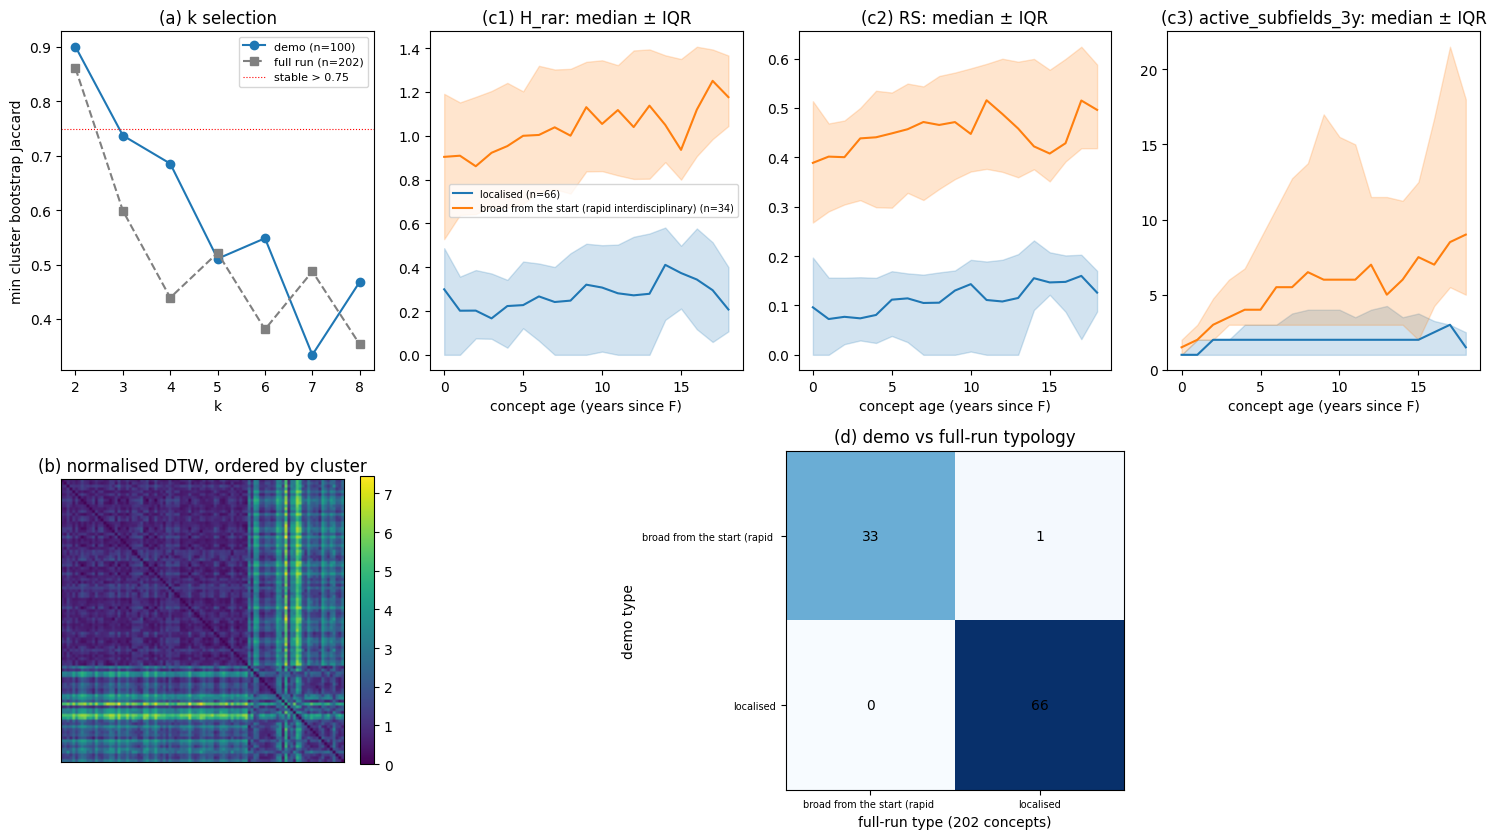

In [21]:
fig = plt.figure(figsize=(15, 8.5))
gs = fig.add_gridspec(2, 4)
# (a) stability by k
ax = fig.add_subplot(gs[0, 0])
ks_ = [int(x) for x in out["by_k"]]
ax.plot(ks_, [out["by_k"][str(x)]["min_jaccard"] for x in ks_], "o-", label=f"demo (n={len(ids)})")
ks_ref = [int(x) for x in ref["by_k"]]
ax.plot(ks_ref, [ref["by_k"][str(x)]["min_jaccard"] for x in ks_ref], "s--", color="grey", label="full run (n=202)")
ax.axhline(JAC_MIN, color="red", lw=0.8, ls=":", label="stable > 0.75")
ax.set_xlabel("k"); ax.set_ylabel("min cluster bootstrap Jaccard"); ax.set_title("(a) k selection"); ax.legend(fontsize=8)
# (b) DTW distance matrix ordered by cluster
ax = fig.add_subplot(gs[1, 0])
o = np.argsort(lab3, kind="stable")
im = ax.imshow(D[np.ix_(o, o)], cmap="viridis"); plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("(b) normalised DTW, ordered by cluster"); ax.set_xticks([]); ax.set_yticks([])
# (c) median trajectories per cluster, per channel
colors = plt.cm.tab10.colors
for j, ch in enumerate(CH):
    ax = fig.add_subplot(gs[0, j + 1])
    for ci, (cl, g) in enumerate(traj.groupby("cluster")):
        g = g[g.n >= 3]
        ax.plot(g.age, g[f"{ch}_0.5"], color=colors[ci], label=f"{names[cl]} (n={sizes[cl]})")
        ax.fill_between(g.age, g[f"{ch}_0.25"], g[f"{ch}_0.75"], color=colors[ci], alpha=0.2)
    ax.set_xlabel("concept age (years since F)"); ax.set_title(f"(c{j + 1}) {ch}: median ± IQR")
    if j == 0:
        ax.legend(fontsize=7)
# (d) demo vs full-run labels
ax = fig.add_subplot(gs[1, 1:])
ctab = pd.crosstab(cmp_.cluster_name, cmp_.full_run_cluster_name)
ax.imshow(ctab.values, cmap="Blues")
for (r, c_), v in np.ndenumerate(ctab.values):
    ax.text(c_, r, int(v), ha="center", va="center")
ax.set_xticks(range(ctab.shape[1])); ax.set_xticklabels([s[:28] for s in ctab.columns], fontsize=7)
ax.set_yticks(range(ctab.shape[0])); ax.set_yticklabels([s[:28] for s in ctab.index], fontsize=7)
ax.set_xlabel("full-run type (202 concepts)"); ax.set_ylabel("demo type"); ax.set_title("(d) demo vs full-run typology")
fig.tight_layout()
plt.show()